# Part 2: ResNet-18 Model Improvement Ablations

This notebook keeps the Part 2 workflow notebook-owned while moving reusable training and result logic into project modules. The regular-training baseline is loaded from Part 1 results; the remaining ablations are trained here.

In [1]:
from pathlib import Path
import importlib
import os
import sys

In [2]:
current = Path.cwd().resolve()
for candidate in [current, *current.parents]:
    if (candidate / 'src').is_dir() and (candidate / 'requirements.txt').exists():
        ROOT = candidate
        break
else:
    ROOT = current

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

In [3]:
def install_project_requirements_for_colab(project_root: Path) -> None:
    """Install non-PyTorch dependencies in Colab without replacing CUDA-matched torch wheels."""
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError:
        return

    import subprocess

    requirements_path = project_root / 'requirements.txt'
    filtered_requirements = Path('/tmp/mlds_colab_requirements.txt')
    skip_prefixes = ('torch', 'torchvision')
    filtered_lines = [
        line
        for line in requirements_path.read_text().splitlines()
        if not line.strip().lower().startswith(skip_prefixes)
    ]
    filtered_requirements.write_text('\n'.join(filtered_lines) + '\n')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(filtered_requirements)])


In [4]:
install_project_requirements_for_colab(ROOT)

ROOT

PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

In [5]:
import pandas as pd
from IPython.display import Image, display

import src.evaluation.experiment_results as experiment_results

experiment_results = importlib.reload(experiment_results)
import src.training.experiment_steps as experiment_steps
experiment_steps = importlib.reload(experiment_steps)
experiment_output_paths = experiment_results.experiment_output_paths
get_device = experiment_results.get_device
load_part1_model_baseline_aggregated = experiment_results.load_part1_model_baseline_aggregated
run_part2_improvement_experiments = experiment_steps.run_part2_improvement_experiments
from src.utils.config import Part2ExperimentConfig
from src.utils.reproducibility import seed_everything

/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [6]:
config = Part2ExperimentConfig()
device = get_device(config)
output_paths = experiment_output_paths(config.results_dir, config.figures_dir, config.part)
seed_everything(config.seed, deterministic=config.deterministic)

pd.DataFrame(
    [
        {
            'part': config.part,
            'config_name': config.config_name,
            'model_name': config.model_name,
            'grid_sizes': config.grid_sizes,
            'num_permutations': config.num_permutations,
            'epochs': config.epochs,
            'device': str(device),
        }
    ]
)

Selected device: cpu


,part,config_name,model_name,grid_sizes,num_permutations,epochs,device
0,part2,part2_improvement,resnet18,"[1, 3]",2,5,cpu


In [7]:
pd.DataFrame(config.ablations)

,name,use_pretrained,use_standard_augmentation,freeze_backbone
0,augmentation_only,True,True,False
1,finetune_only,True,False,False
2,augmentation_finetune,True,True,False


## Part 1 ResNet-18 Baseline

In [8]:
part1_baseline_aggregated = load_part1_model_baseline_aggregated(config, config.model_name)
if not part1_baseline_aggregated.empty:
    display(part1_baseline_aggregated)

,model_name,grid_size,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs,ablation_name,config_name
0,resnet18,1,1,0.865385,NaN,0.903846,NaN,1,regular_part1,part2_improvement
1,resnet18,3,9,0.903846,0.05088,0.929487,0.011103,3,regular_part1,part2_improvement


## Train Improvement Ablations

In [9]:
RUN_TRAINING = True

if RUN_TRAINING:
    part2_results = run_part2_improvement_experiments(config=config, device=device)
    display(part2_results)
else:
    print('Training is skipped. Set RUN_TRAINING = True to train Part 2 ablations in this notebook.')


Running ablation: augmentation_only

[1/4] grid=1x1, permutation_id=0, seed=42
Building training components for model 'resnet18'...
Finished building training components for model 'resnet18'.
Training model 'resnet18' for 5 epoch(s)...


resnet18 epochs: 100%|██████████| 5/5 [03:00<00:00, 36.19s/epoch, best_val_accuracy=0.981, train_accuracy=0.971, train_loss=0.0602, val_accuracy=0.981, val_loss=0.146] 


Finished training model 'resnet18'. Metrics: {'train_loss': 0.06017392727674222, 'train_accuracy': 0.9705882352941176, 'val_loss': 0.14621773548424244, 'val_accuracy': 0.9807692307692307, 'best_val_accuracy': 0.9807692307692307}

[2/4] grid=3x3, permutation_id=0, seed=42
Building training components for model 'resnet18'...
Finished building training components for model 'resnet18'.
Training model 'resnet18' for 5 epoch(s)...


resnet18 epochs: 100%|██████████| 5/5 [03:29<00:00, 41.86s/epoch, best_val_accuracy=0.942, train_accuracy=0.995, train_loss=0.0184, val_accuracy=0.942, val_loss=0.15] 


Finished training model 'resnet18'. Metrics: {'train_loss': 0.018403162134299968, 'train_accuracy': 0.9950980392156863, 'val_loss': 0.14959440623911527, 'val_accuracy': 0.9423076923076923, 'best_val_accuracy': 0.9423076923076923}

[3/4] grid=3x3, permutation_id=1, seed=42
Building training components for model 'resnet18'...
Finished building training components for model 'resnet18'.
Training model 'resnet18' for 5 epoch(s)...


...

resnet18 epochs: 100%|██████████| 5/5 [02:58<00:00, 35.60s/epoch, best_val_accuracy=0.885, train_accuracy=0.936, train_loss=0.154, val_accuracy=0.865, val_loss=0.393]


Finished training model 'resnet18'. Metrics: {'train_loss': 0.1538305175216759, 'train_accuracy': 0.9362745098039216, 'val_loss': 0.3931463314936711, 'val_accuracy': 0.8653846153846154, 'best_val_accuracy': 0.8846153846153846}

[4/4] grid=3x3, permutation_id=2, seed=42
Building training components for model 'resnet18'...
Finished building training components for model 'resnet18'.
Training model 'resnet18' for 5 epoch(s)...


resnet18 epochs: 100%|██████████| 5/5 [02:54<00:00, 34.94s/epoch, best_val_accuracy=0.962, train_accuracy=0.961, train_loss=0.108, val_accuracy=0.846, val_loss=0.377]


Finished training model 'resnet18'. Metrics: {'train_loss': 0.10773556807315816, 'train_accuracy': 0.9607843137254902, 'val_loss': 0.37740777089045596, 'val_accuracy': 0.8461538461538461, 'best_val_accuracy': 0.9615384615384616}


,model_name,ablation_name,grid_size,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,augmentation_finetune,1,1,0.769231,NaN,0.961538,NaN,1
1,resnet18,augmentation_finetune,3,9,0.878205,0.040032,0.935897,0.044412,3
2,resnet18,augmentation_only,1,1,0.980769,NaN,0.980769,NaN,1
3,resnet18,augmentation_only,3,9,0.916667,0.029375,0.935897,0.029375,3
4,resnet18,finetune_only,1,1,0.923077,NaN,0.923077,NaN,1
5,resnet18,finetune_only,3,9,0.923077,0.019231,0.935897,0.040032,3
6,resnet18,regular_part1,1,1,0.865385,NaN,0.903846,NaN,1
7,resnet18,regular_part1,3,9,0.903846,0.050880,0.929487,0.011103,3


## Results

In [10]:
results_path = Path(output_paths['aggregated_results'])

if results_path.exists():
    part2_results = pd.read_csv(results_path)
    if 'regular_part1' not in set(part2_results.get('ablation_name', [])) and not part1_baseline_aggregated.empty:
        part2_results = pd.concat([part1_baseline_aggregated, part2_results], ignore_index=True, sort=False)
    display(part2_results.sort_values(['grid_size', 'ablation_name']))
else:
    print('Part 2 aggregated results were not found. Set RUN_TRAINING = True and run the training cell.')
    if part1_baseline_aggregated.empty:
        print('Part 1 ResNet-18 baseline results were also not found; run Part 1 first to include regular_part1.')

,model_name,ablation_name,grid_size,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,augmentation_finetune,1,1,0.769231,NaN,0.961538,NaN,1
2,resnet18,augmentation_only,1,1,0.980769,NaN,0.980769,NaN,1
4,resnet18,finetune_only,1,1,0.923077,NaN,0.923077,NaN,1
6,resnet18,regular_part1,1,1,0.865385,NaN,0.903846,NaN,1
1,resnet18,augmentation_finetune,3,9,0.878205,0.040032,0.935897,0.044412,3
3,resnet18,augmentation_only,3,9,0.916667,0.029375,0.935897,0.029375,3
5,resnet18,finetune_only,3,9,0.923077,0.019231,0.935897,0.040032,3
7,resnet18,regular_part1,3,9,0.903846,0.050880,0.929487,0.011103,3


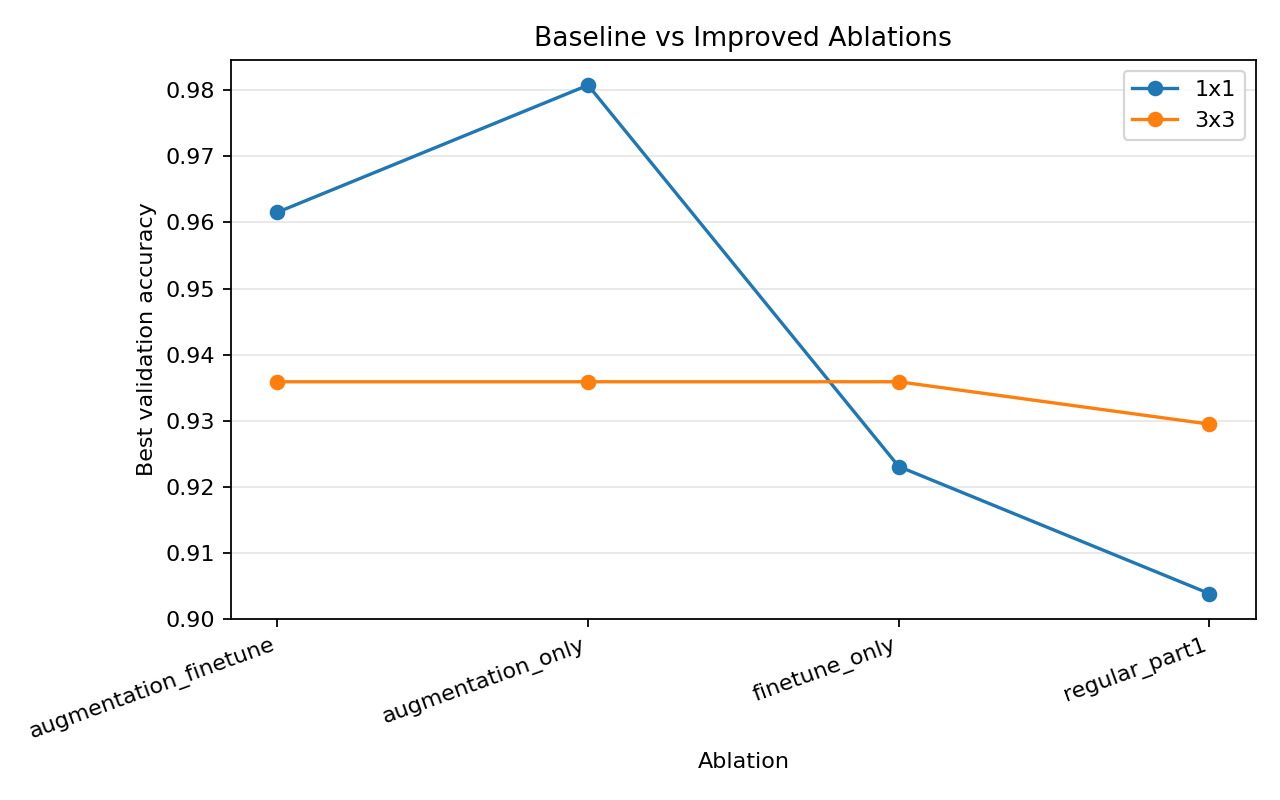

In [11]:
figure_path = Path(output_paths['figure'])
if figure_path.exists():
    display(Image(filename=str(figure_path)))
else:
    print('Part 2 ablation figure has not been generated yet.')